# 👋 Welcome to the introduction tutorial

In this tutorial, we will guide you, while using *puncc*, throughout the process of uncertainty quantification in a regression tasks. By the end of this notebook, you will be able to wrap your own models into conformal predictors and analyze their performance.

In addition, we will provide a guide on how to use conformal prediction for anomaly detection. Let's get started !

**Table of contents**

- [📈 Conformal Regression](#cr)
    - [💾 Diabetes Dataset](#cr-data)
    - [🔮 Predicton Model](#cr-pm)
    - [⚙️ Conformal Prediction](#cr-cp)
- [🚩 Conformal Anomaly Detection](#cad)
    - [💾 Two moons Dataset](#cad-data)
    - [🔮 Anomaly detector](#cad-pm)
    - [⚙️ Conformal Anomaly Detection](#cad-cp)


**Links**
- [<img src="https://github.githubassets.com/images/icons/emoji/octocat.png" width=20> Github](https://github.com/deel-ai/puncc)
- [📘 Documentation](https://deel-ai.github.io/puncc/index.html)

In [1]:
!pip install puncc

/bin/bash: line 1: pip: command not found


## 🛠️ Backend Configuration

**Puncc** supports various data types and model types.  
For this introductory notebook, we set the backend to NumPy.

In [2]:
from deel.puncc.config import set_backend

set_backend("numpy")

## 📈 Conformal Regression  <a class="anchor" id="cr"></a>

Let’s consider a simple regression problem on diabetes data provided in Scikit-learn. We want to evaluate the uncertainty associated with the prediction using inductive (or split) conformal prediction.

### 💾 Diabetes Dataset <a class="anchor" id="cr-data"></a>

The dataset contains information about 442 diabetes patients. The goal is predict from physiological variables a quantitative measure of disease progression in one year.
- There are ten standardized features corresponding to the age, sex, body mass index, average blood pressure, and six blood serum measurements. 
- The target is the measure of diabetes progression during one year for each patient.

For more information, check the official [documentation](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html).

In [3]:
from sklearn import datasets

# Load the diabetes dataset
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

print(f"Features shape: {diabetes_X.shape}")
print(f"Target's shape: {diabetes_y.shape}")

Features shape: (442, 10)
Target's shape: (442,)


From all the features, we want our model to capture only the link between body mass index and the evolution of the disease. 

In [4]:
import numpy as np 

# Use only BMI feature
diabetes_X = diabetes_X[:, 2, np.newaxis]

By construction, data are independent and identically distributed (i.i.d).

Great, we fullfill the prerequisites to apply conformal prediction 👏 !

The next step is spliting the data into three subsets:

* Fit subset ${\cal D_{fit}}$ to train the model.
* Calibration subset ${\cal D_{calib}}$ on which nonconformity scores are
  computed.
* Test subset ${\cal D_{test}}$ on which the prediction intervals are
  estimated.

---
**NOTE**

   Rigorously, for the probabilistic guarantee to hold, the calibration subset
   needs to be resampled for each new example in the test set.

---


The following code implements the aforementioned steps:

In [5]:
# Split the data into training/testing sets
X_train = diabetes_X[:-100]
X_test = diabetes_X[-100:]

# Split the targets into training/testing sets
y_train = diabetes_y[:-100]
y_test = diabetes_y[-100:]

# Split fit and calibration data
X_fit, X_calib = X_train[:-100], X_train[-100:]
y_fit, y_calib = y_train[:-100], y_train[-100:]

### 🔮 Prediction Model <a class="anchor" id="cr-pm"></a>

We consider a simple linear regression model from
[scikit-learn regression module](https://scikit-learn.org/stable/modules/linear_model.html),
to be trained later on ${\cal D_{fit}}$:

In [6]:
from sklearn import linear_model

# Create linear regression model
lin_reg_predictor = linear_model.LinearRegression()

### ⚙️ Conformal Prediction <a class="anchor" id="cr-cp"></a>

For this example, the prediction intervals are obtained throught the split
conformal prediction method provided by the class
`deel.puncc.regression.SplitCP`. Other methods are presented
in the [documentation](https://deel-ai.github.io/puncc/regression.html).

In [7]:
from deel.puncc.regression import SplitCP

# Coverage target is 1-alpha = 90%
alpha=.1

# Instanciate the split cp wrapper around the linear predictor.
split_cp = SplitCP(lin_reg_predictor)

# Train model (if argument `is_train` is False) on the fitting dataset and
# compute the residuals on the calibration dataset. 
split_cp.fit(X_fit, y_fit)
split_cp.calibrate(X_calib, y_calib)

## Alternatively, we can randomly select the fit/calib subsets as below 
# split_cp.fit(X=X_train, y=y_train, fit_ratio=.8)

# The `predict` returns the output of the linear model `y_pred` and
# the calibrated interval [`y_pred_lower`, `y_pred_upper`].
y_pred, y_set= split_cp.predict(X_test, alpha=alpha)
y_pred_lower, y_pred_upper = y_set[..., 0], y_set[..., 1]

The library provides several metrics in `deel.puncc.metrics` to evaluate the conformalization procedure. Below, we compute the average empirical coverage and the average empirical width of the prediction intervals on the test examples:

In [8]:
from deel.puncc import metrics

coverage = metrics.regression_mean_coverage(y_test, y_pred_lower, y_pred_upper)
width = metrics.regression_sharpness(y_pred_lower=y_pred_lower,
                                    y_pred_upper=y_pred_upper)
print(f"Marginal coverage: {coverage:.2f}")
print(f"Average width: {width:.2f}")

Marginal coverage: 0.95
Average width: 211.38


In addition, puncc provides plotting tools in `deel.puncc.plotting` to visualize the prediction intervals and whether or not the observations are covered:

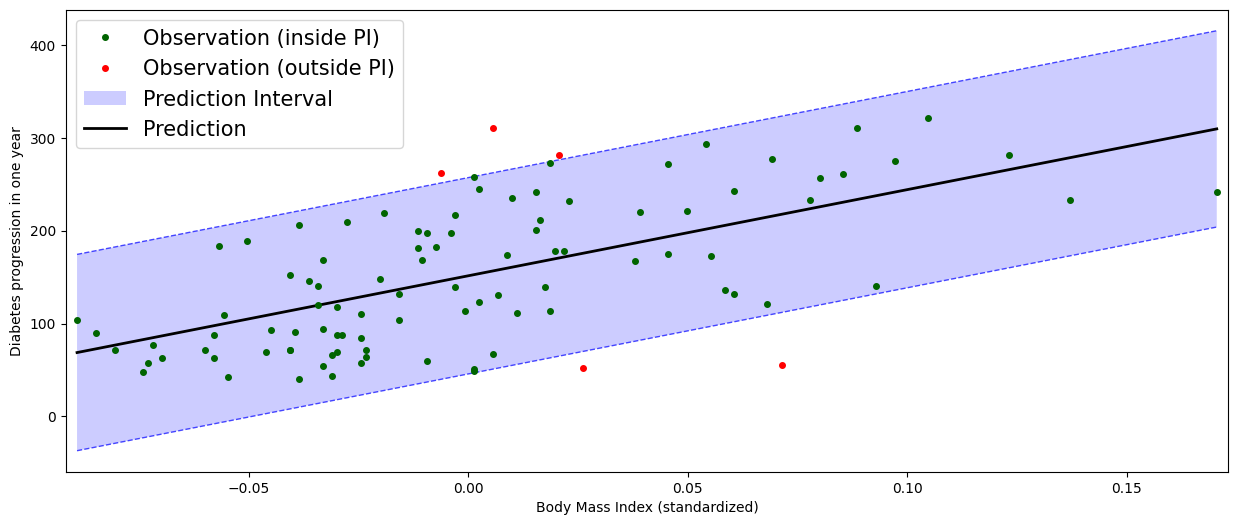

In [9]:
from deel.puncc.plotting import plot_prediction_intervals

# Figure of the prediction bands

ax = plot_prediction_intervals(
        X = X_test[:,0],
        y_true=y_test,
        y_pred=y_pred,
        y_pred_lower=y_pred_lower,
        y_pred_upper=y_pred_upper,
        loc="upper left")

_ = ax.set_xlabel("Body Mass Index (standardized)")
_ = ax.set_ylabel("Diabetes progression in one year")

## 🚩 Conformal Anomaly Detection  <a class="anchor" id="cad"></a>

Let's consider the two moons dataset and a collection of data points randomly scattered across a plane. Among these points, some will stand out as outliers, deviating significantly from the crescent-shaped clusters. Using an isolation forest algorithm, we generate anomaly scores for each data point. Subsequently, we wrap the model with conformal anomaly detection to calibrate the detection threshold. This ensures that the False Detection Rate (FDR) remains below the user-specified threshold $\alpha$.

### 💾 Two moons Dataset <a class="anchor" id="cc-data"></a>

The two moons dataset is a synthetic dataset that consists of two crescent-shaped clusters of points. It is a popular dataset for evaluating anomaly detection algorithms because it is easy to visualize and has a well-defined structure. In the code below, we generate 5000 examples from the two moons distribution. In addition, we generate 300 new points distributed uniformly across the plane.

In [10]:
import numpy as np
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

n_samples = 5000
n_new = 350

# We generate the two moons dataset
dataset = 4 * make_moons(n_samples=n_samples, noise=0.05, random_state=42)[
    0
] - np.array([0.5, 0.25])

# We generate uniformly new (test) data points
rng = np.random.RandomState(42)
z_test = rng.uniform(low=-6, high=10, size=(n_new, 2))

### 🔮 Anomaly detection Model <a class="anchor" id="cad-pm"></a>

We use the isolation forest (IF) algorithm to produce anomaly scores. Such model will be trained in the following section.

In [11]:
from sklearn.ensemble import IsolationForest

ad_model = IsolationForest(random_state=42) 

# Note that any other model could have been used, such as LOF:
# from sklearn.neighbors import LocalOutlierFactor
# ad_model = LocalOutlierFactor(n_neighbors=35, novelty=True)

Similarily to conformal regression and conformal classification, the underlying model needs to be wrapped in a wrapper provided in the module `deel.puncc.api.prediction`.
By default, the method `score_samples` returns the opposite of anomaly scores. We need to redefine the `predict` call to output the anomaly score:

In [12]:
# We redefine the predict method to return the opposite of IF scores
class ADPredictor():
    def __init__(self, model):
        self.model = model
    def fit(self, *args, **kwargs):
        return self.model.fit(*args, **kwargs)
    def predict(self, X):
        return -self.model.score_samples(X)

# wrap the (IF) anomaly detection model in a predictor
if_predictor = ADPredictor(ad_model)

### ⚙️ Conformal Anomaly Detection <a class="anchor" id="cad-cp"></a>

The `deel.puncc.anomaly_detection.SplitCAD` wrapper is used to train and calibrate the IF anomaly detector  using 70% and 30% of the two moons dataset, respectively. 

In [13]:
from deel.puncc.anomaly_detection import SplitCAD

# Instantiate CAD on top of IF predictor
if_cad = SplitCAD(if_predictor, train=True, random_state=0)

# Fit the IF on the proper fitting dataset and
# calibrate it using calibration dataset.
# The two datasets are sampled randomly with a ration of 7:3,
# respectively.
if_cad.fit(z=dataset, fit_ratio=0.7)

Now, we call CAD to obtain conformal anomaly detections: 

In [14]:
# We set the maximum false detection rate to 5%
alpha = 0.05
# The method `predict` is called on the new data points
# to test which are anomalous and which are not
cad_results = if_cad.predict(z_test, alpha=alpha)
cad_anomalies = z_test[cad_results]
cad_not_anomalies = z_test[np.invert(cad_results)]

Let's compare the results before and after the calibration. 

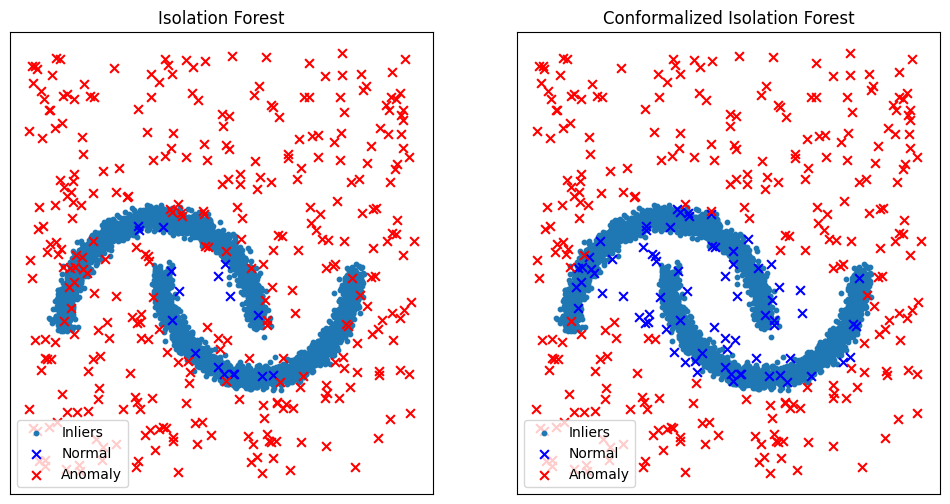

In [15]:
# Detect anomalies with underlying IF model (no conformal)
if_results = if_cad.predictor.model.predict(z_test) == 1
if_not_anomalies = z_test[if_results]
if_anomalies = z_test[np.invert(if_results)]

fig, ax = plt.subplots(ncols=2, figsize=(12, 6), sharex=True, sharey=True)

# Plot if results

ax[0].scatter(dataset[:, 0], dataset[:, 1], s=10, label="Inliers")
ax[0].scatter(
    if_not_anomalies[:, 0],
    if_not_anomalies[:, 1],
    s=40,
    marker="x",
    color="blue",
    label="Normal",
)
ax[0].scatter(
    if_anomalies[:, 0],
    if_anomalies[:, 1],
    s=40,
    marker="x",
    color="red",
    label="Anomaly",
)
ax[0].set_xticks(())
ax[0].set_yticks(())
ax[0].set_title("Isolation Forest")
ax[0].legend(loc="lower left")

# Plot cad results
ax[1].scatter(dataset[:, 0], dataset[:, 1], s=10, label="Inliers")
ax[1].scatter(
    cad_not_anomalies[:, 0],
    cad_not_anomalies[:, 1],
    marker="x",
    color="blue",
    s=40,
    label="Normal",
)
ax[1].scatter(
    cad_anomalies[:, 0],
    cad_anomalies[:, 1],
    marker="x",
    color="red",
    s=40,
    label="Anomaly",
)
ax[1].set_xticks(())
ax[1].set_yticks(())
ax[1].set_title("Conformalized Isolation Forest")
ax[1].legend(loc="lower left")

See how conformal anomaly detection reduces false alarms !

# 🎉 Congratulations
**You are now familiar with basics of conformal prediction with puncc !**

To go further, check the [**API tutorial**](api_intro.ipynb) to build your own conformal prediction algorithms !